In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text

sc.settings.verbosity = 2

# Load in TF-associated networks

In [2]:
# MYOD1
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/MYOD_network_1storder_300.csv"
mdf = pd.read_csv(path1, index_col=0)
print(mdf.shape)
display(mdf.head())


# PRRX1
path2 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/PRRX1_network_1storder_300.csv"
pdf = pd.read_csv(path2, index_col=0)
print(pdf.shape)
display(pdf.head())

(545, 545)


,MYOD1,CD99,KDM1A,PDK4,CALCR,HOXA11,MEOX1,CREBBP,SOX8,IFRD1,...,INS,ENSG00000255071,EID1,SCX,DUX4,PECAM1,MYMX,MYH4,H3-7,DACH1
MYOD1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
CD99,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
KDM1A,1,0,1,1,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
PDK4,1,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
CALCR,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


(196, 196)


,PRRX1,COPZ2,TFAP2B,METTL13,DCN,SNAI2,VIM,CD44,CDH1,PHF23,...,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,HOXB7,SCX,GTF2I
PRRX1,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
COPZ2,1,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
TFAP2B,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
METTL13,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DCN,1,0,0,0,0,1,1,1,1,0,...,1,0,0,0,0,1,0,0,1,0


## Make graphs

In [28]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"N nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")


# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"N nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

N nodes: 545
N edges: 29898
N nodes: 196
N edges: 4055


In [29]:
## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
print(len(myod_nodes))

prrx_nodes = list(GP.nodes())
print(len(prrx_nodes))

545
196


In [30]:
# fibroblast genes
path1 = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/fibGenes_network_1storder_300.csv"
fdf = pd.read_csv(path1, index_col=0)
print(fdf.shape)
display(fdf.head())

GF = nx.from_pandas_adjacency(fdf, create_using=nx.Graph) # keeps self-loops
GF.remove_edges_from(nx.selfloop_edges(GF)) # remove self-loops

print(f"N nodes: {GF.number_of_nodes()}\nN edges: {GF.number_of_edges()}")

fibgenes_nodes = list(GF.nodes())


# graph density
n_edges = GF.number_of_edges()
n_nodes = GF.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

(231, 231)


,TNFRSF1B,PODN,VCAM1,GSTM5,OLFML3,DDR2,PBX1,PRRX1,FMO2,LAMC1,...,EDN3,ADAM33,COL6A1,COL6A2,ADAMTS5,RUNX1,TIMP3,SRPX2,BGN,MXRA5
TNFRSF1B,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PODN,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
VCAM1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,1,1,0,1,0
GSTM5,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
OLFML3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1


N nodes: 231
N edges: 4118
Graph density: 0.1550


# Load in adata

In [3]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.42 GB, difference +2.42 GB
CPU times: user 505 ms, sys: 1.45 s, total: 1.95 s
Wall time: 6.74 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [4]:
# Load TFs
fpath = "../../resources/HumanTF_v_1.01.csv"

tdf = pd.read_csv(fpath)

tdf = tdf[['HGNC symbol', 'Is TF?']]
tdf = tdf.rename(columns={'HGNC symbol': 'gene_name', 'Is TF?': 'is_tf'})
tdf = tdf[tdf['is_tf'] == 'Yes']
tdf = tdf.drop_duplicates(subset='gene_name')
display(tdf.head())

# extract unique TFs
tf_list = tdf['gene_name'].unique()
print(len(tf_list))

tf_list = [g for g in tf_list if g in adata.var_names]

print(len(tf_list))

,gene_name,is_tf
0,TFAP2A,Yes
1,TFAP2B,Yes
2,TFAP2C,Yes
3,TFAP2D,Yes
4,TFAP2E,Yes


1639
1358


# Subset for control cells

In [23]:
fdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()
print(fdata.shape)

(6902, 25126)


In [6]:
# tf_list1 = [g for g in tf_list if g in fdata.var_names]

# tmp = fdata[:, tf_list1].copy()

# tmp.X = tmp.layers['raw_counts'].copy()

# X = tmp.X if isinstance(tmp.X, np.ndarray) else tmp.X.toarray()

# X_df = pd.DataFrame(
#     X,
#     index=tmp.obs_names,
#     columns=tmp.var_names,
# )

# X_df.head()

gene_name,TFAP2A,TFAP2C,TFAP2E,ARID3A,ARID3B,ARID5A,ARID5B,KDM5B,ARID2,AHCTF1,...,SON,SPEN,SPZ1,TCF20,TET2,THYN1,TMF1,TOPORS,TSC22D1,XPA
AAACCAAAGGGTAGCA_control,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,...,5.0,0.0,0.0,1.0,0.0,1.0,4.0,0.0,1.0,0.0
AAACCAAAGTAAGGGT_control,0.0,0.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,...,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
AAACCATTCAGGTAGG_control,0.0,0.0,0.0,1.0,1.0,0.0,5.0,0.0,1.0,0.0,...,5.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0
AAACCATTCCAGCCCT_control,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,4.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0
AAACCATTCGTGACCG_control,4.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,...,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# filter genes (specific to controls)

fdata.X = fdata.layers['raw_counts'].copy()

sc.pp.filter_genes(fdata, min_counts=10) # param used for original processing

sc.pp.normalize_total(fdata, target_sum=1e4)

fdata.layers['CP10K'] = fdata.X.copy()

# X = fdata.X
# vals = X.data if sp.issparse(X) else X.ravel()

# print("X dtype:", vals.dtype)
# print("X min/max:", float(vals.min()), float(vals.max()))
# print("fraction non-integer:", float(np.mean(vals % 1 != 0)))
# print("fraction <= ~20:", float(np.mean(vals <= 20)))


sc.pp.log1p(fdata)

fdata.layers['log_norm_new'] = fdata.X.copy()


fdata

filtered out 5165 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 6902 × 19961
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [18]:
['MYOD1' in fdata.var_names]

[False]

# Detected genes

In [31]:
### Which genes are present in adata?

# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 391
154 genes not detected.

N prrx1 nodes in fdata: 170
26 genes not detected.


In [32]:
sub_GM = GM.subgraph(myod_genes)
print(f"N nodes: {sub_GM.number_of_nodes()}\nN edges: {sub_GM.number_of_edges()}")

sub_GP = GP.subgraph(prrx_genes)
print(f"\nN nodes: {sub_GP.number_of_nodes()}\nN edges: {sub_GP.number_of_edges()}")

N nodes: 391
N edges: 16796

N nodes: 170
N edges: 3068


In [ ]:
## Before re-filtering genes
# N myod nodes in fdata: 451
# 94 genes not detected.

# N prrx1 nodes in fdata: 180
# 16 genes not detected.

In [33]:
fib_genes = [
    g for g in fibgenes_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_fib_genes = list(set(fibgenes_nodes) - set(fib_genes))

print(f"N fibgenes nodes in fdata: {len(fib_genes)}")
print(f"{len(missing_fib_genes)} genes not detected.\n")


sub_GF = GF.subgraph(fib_genes)
print(f"\nN nodes: {sub_GF.number_of_nodes()}\nN edges: {sub_GF.number_of_edges()}")

N fibgenes nodes in fdata: 208
23 genes not detected.


N nodes: 208
N edges: 3859


# Pseudobulk

In [22]:
# Pseudobulk -- Y or N for nodes
aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()


aggdata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 1 × 19961
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'

In [25]:
aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

(19961, 2)


,gene_name,Control
0,A1BG,0.556132
1,A1BG-AS1,0.040971
2,A2M,0.121208
3,A2M-AS1,0.002791
4,A4GALT,0.045369


In [31]:
print(f"Mean expression across all genes: {df['Control'].mean()}")
print(f"Median expression across all genes: {df['Control'].median()}")

Mean expression across all genes: 0.1985432886225451
Median expression across all genes: 0.04974683678395762


In [32]:
df[df['gene_name'] == 'PRRX1']

,gene_name,Control
14460,PRRX1,1.033052


In [34]:
# add TF column
df['is_tf'] = df['gene_name'].isin(tf_list)

print(df['is_tf'].value_counts())
df.head()

is_tf
False    18714
True      1247
Name: count, dtype: int64


,gene_name,Control,is_tf
0,A1BG,0.556132,False
1,A1BG-AS1,0.040971,False
2,A2M,0.121208,False
3,A2M-AS1,0.002791,False
4,A4GALT,0.045369,False


In [43]:
display(df.groupby('is_tf')['Control'].describe())
df.groupby('is_tf')['Control'].median()

,count,mean,std,min,25%,50%,75%,max
is_tf,,,,,,,,
False,18714.0,0.202285,0.420148,0.000998,0.006566,0.048083,0.204615,5.529708
True,1247.0,0.142390,0.239045,0.000998,0.024112,0.060891,0.152158,2.741045


is_tf
False    0.048083
True     0.060891
Name: Control, dtype: float64

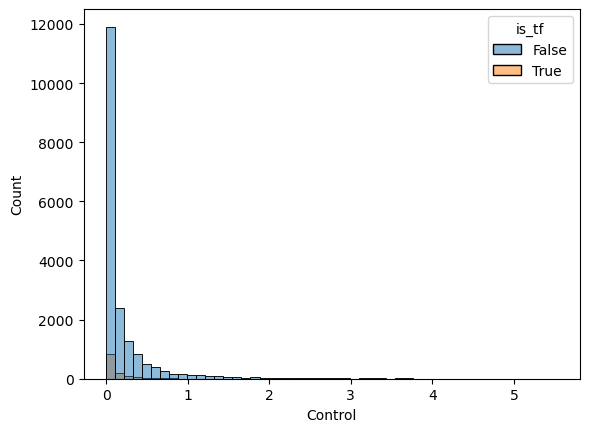

In [36]:
sns.histplot(
    data=df,
    x='Control',
    hue='is_tf',
    bins=50,
)

plt.show()

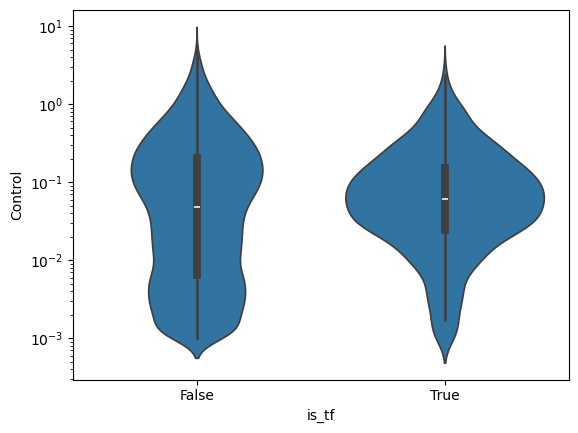

In [42]:
sns.violinplot(
    data=df,
    y='Control',
    x='is_tf',
    log_scale=True,
)

plt.show()

In [48]:
# make expression bins

q_low = 0.25
q_high = 0.75

# Calculate thresholds for TFs and non-TFs separately
non_tf_low = df[~df['is_tf']]['Control'].quantile(q_low)
non_tf_high = df[~df['is_tf']]['Control'].quantile(q_high)

tf_low = df[df['is_tf']]['Control'].quantile(q_low)
tf_high = df[df['is_tf']]['Control'].quantile(q_high)

print("Non-TF thresholds:", non_tf_low, non_tf_high)
print("TF thresholds:", tf_low, tf_high)

def assign_expr_level(row):
    if row['is_tf']:
        if row['Control'] < tf_low:
            return 'low'
        elif row['Control'] > tf_high:
            return 'high'
        else:
            return 'mid'
    else:
        if row['Control'] < non_tf_low:
            return 'low'
        elif row['Control'] > non_tf_high:
            return 'high'
        else:
            return 'mid'

df['expr_level'] = df.apply(assign_expr_level, axis=1)

df.head()

Non-TF thresholds: 0.006566123996383339 0.20461457897130192
TF thresholds: 0.024111504776474744 0.15215767044599193


,gene_name,Control,is_tf,expr_level
0,A1BG,0.556132,False,high
1,A1BG-AS1,0.040971,False,mid
2,A2M,0.121208,False,mid
3,A2M-AS1,0.002791,False,low
4,A4GALT,0.045369,False,mid


In [49]:
df['expr_level'].value_counts()

expr_level
mid     10002
high     4991
low      4968
Name: count, dtype: int64

## Subset for myod_genes

In [50]:
df1 = df[df['gene_name'].isin(myod_genes)]

print(df1.shape)
df1.head()

(391, 4)


,gene_name,Control,is_tf,expr_level
150,ACP1,0.635542,False,high
169,ACTB,3.573129,False,high
170,ACTC1,0.073397,False,mid
192,ACVR1B,0.036073,False,mid
194,ACVR2A,0.058917,False,mid


In [51]:
df1['Control'].describe()

count    391.000000
mean       0.385578
std        0.610563
min        0.000998
25%        0.031538
50%        0.147991
75%        0.448075
max        3.704403
Name: Control, dtype: float64

In [52]:
df1.sort_values(by='Control').head()

,gene_name,Control,is_tf,expr_level
16113,SIX2,0.000998,True,low
18607,UCP1,0.000998,False,low
1771,CALML6,0.000998,False,low
9660,IGFN1,0.000998,False,low
12331,MYF6,0.001097,True,low


In [30]:
print(df1['Control'].median())

0.14799135710206449


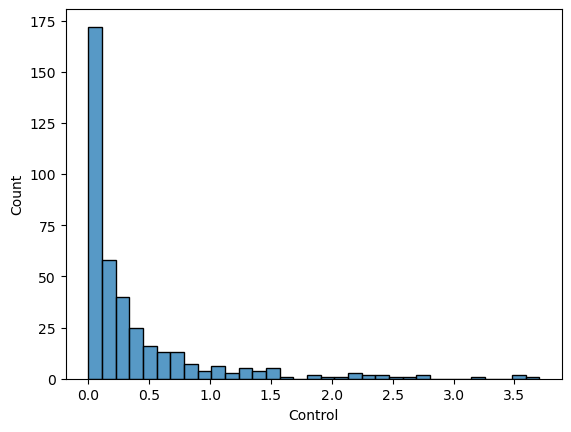

In [27]:
sns.histplot(
    df1['Control']
)

plt.show()

In [54]:
print(df1['expr_level'].value_counts())

df1['expr_level'].value_counts(normalize=True)

expr_level
high    178
mid     154
low      59
Name: count, dtype: int64


expr_level
high    0.455243
mid     0.393862
low     0.150895
Name: proportion, dtype: float64

## Subset for prrx_genes

In [55]:
df2 = df[df['gene_name'].isin(prrx_genes)]

print(df2.shape)
df2.head()

(170, 4)


,gene_name,Control,is_tf,expr_level
168,ACTA2,0.604891,False,high
191,ACVR1,0.157757,False,mid
259,ADD3,0.427036,False,high
315,AEBP1,1.334235,True,high
653,AOPEP,0.398835,False,high


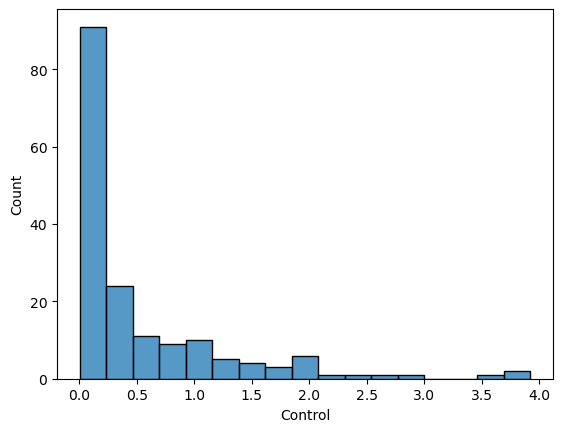

In [56]:
sns.histplot(
    df2['Control']
)

plt.show()

In [57]:
print(df2['expr_level'].value_counts())

df2['expr_level'].value_counts(normalize=True)

expr_level
high    85
mid     63
low     22
Name: count, dtype: int64


expr_level
high    0.500000
mid     0.370588
low     0.129412
Name: proportion, dtype: float64

# Gene-gene correlation

In [50]:
fdata

AnnData object with n_obs × n_vars = 6902 × 19961
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [ ]:
fdata.X = fdata.layers['log_norm'].copy()



In [37]:
# fdata.write("/scratch/indikar_root/indikar1/jrcwycy/HYB/HWG/control_adata.h5ad")

In [12]:
fdata.X = fdata.layers['log_norm'].copy()

corr_method = 'spearman'
# corr_method = 'pearson'

# MYOD1 genes
mdata = fdata[:, myod_genes].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=mdata.obs_names,
    columns=mdata.var_names,
)

RM = X_df.corr(method=corr_method)
print(RM.shape)
display(RM.head())


# PRRX1 genes
pdata = fdata[:, prrx_genes].copy()
print(pdata.shape)

X = pdata.X if isinstance(pdata.X, np.ndarray) else pdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=pdata.obs_names,
    columns=pdata.var_names,
)

RP = X_df.corr(method=corr_method)
print(RP.shape)
display(RP.head())

(6902, 391)
(391, 391)


gene_name,CD99,KDM1A,HOXA11,CREBBP,IFRD1,NFIX,DCN,ISL1,IGF1,SNAI2,...,PHB2,EBF2,CEBPD,CCNL2,TNF,TWIST2,BGLAP,EID1,SCX,H3-7
gene_name,,,,,,,,,,,,,,,,,,,,,
CD99,1.000000,0.014489,0.034105,0.031450,0.010454,0.047138,0.100376,0.009157,0.006970,0.007216,...,-0.032811,0.009390,0.032639,0.016012,-0.022610,0.005467,0.009362,-0.011366,-0.003078,0.000180
KDM1A,0.014489,1.000000,0.000949,0.037493,0.009649,0.043504,-0.089661,0.019152,-0.018710,0.051705,...,0.014919,0.020068,-0.030026,-0.005833,0.014854,-0.018810,0.010620,0.025257,-0.001050,0.011233
HOXA11,0.034105,0.000949,1.000000,0.015019,0.015647,-0.005922,-0.019212,-0.002786,0.026162,0.024262,...,0.005978,-0.002873,-0.020210,0.001066,0.002884,0.022036,-0.013356,0.008600,0.005190,0.010119
CREBBP,0.031450,0.037493,0.015019,1.000000,0.013079,0.063955,0.029825,0.025157,0.019903,0.033936,...,0.011452,-0.007211,0.005202,0.014925,0.005613,0.040406,0.018576,0.014592,-0.005530,0.025297
IFRD1,0.010454,0.009649,0.015647,0.013079,1.000000,-0.004033,-0.016309,-0.015160,0.012811,0.011084,...,0.010822,0.000211,-0.010965,0.012139,-0.004522,0.006492,0.008694,-0.017029,-0.008155,0.001644


(6902, 170)
(170, 170)


gene_name,PRRX1,COPZ2,METTL13,DCN,SNAI2,VIM,CD44,PHF23,FOXC1,SYNE2,...,BMPR2,COL5A2,POU5F1,VGLL3,EBF2,TWIST2,BGLAP,FOXD1,SCX,GTF2I
gene_name,,,,,,,,,,,,,,,,,,,,,
PRRX1,1.000000,-0.012920,-0.007905,0.089799,0.037524,0.006337,0.134837,0.033898,-0.016941,0.004250,...,0.063694,0.009709,0.001404,-0.028498,-0.006862,0.087684,-0.002023,-0.009340,0.003101,0.016518
COPZ2,-0.012920,1.000000,0.001595,-0.016970,0.005042,0.007596,-0.016082,-0.003254,-0.002509,-0.021511,...,0.016367,0.013694,0.002386,0.013260,0.003500,-0.027928,0.002801,-0.003680,0.013957,-0.010233
METTL13,-0.007905,0.001595,1.000000,-0.062836,0.012104,0.056421,0.028516,-0.010659,0.009319,0.044681,...,0.007599,-0.000217,-0.005096,0.003082,-0.015755,0.006093,0.008038,0.024056,0.010901,-0.003195
DCN,0.089799,-0.016970,-0.062836,1.000000,-0.043510,-0.396613,-0.014782,0.029023,-0.025934,-0.174541,...,0.040769,0.111262,0.012236,0.011122,-0.001857,0.098380,-0.023849,-0.065499,-0.001835,0.014816
SNAI2,0.037524,0.005042,0.012104,-0.043510,1.000000,0.112559,0.034466,0.010044,0.005663,0.031743,...,0.059039,0.032779,0.006069,0.022325,-0.011483,0.020408,-0.007887,0.028979,-0.020924,0.029644


In [19]:
# MYOD1
edges = pd.DataFrame(sub_GM.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RM.loc[g1, g2] if g1 in RM.index and g2 in RM.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()

(16796, 2)


,gene1,gene2,corr
0,CD99,PTPRC,0.008065
1,CD99,ESR1,-0.004282
2,CD99,SMARCB1,0.018123
3,CD99,SOX10,-0.002464
4,CD99,SYP,-0.009584


In [21]:
threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold


fraction = edges["above_thresh"].mean()
print(fraction)

0.03691355084543939


In [22]:
# PRRX1
edges = pd.DataFrame(sub_GP.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RP.loc[g1, g2] if g1 in RP.index and g2 in RP.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()

(3068, 2)


,gene1,gene2,corr
0,PRRX1,COPZ2,-0.012920
1,PRRX1,METTL13,-0.007905
2,PRRX1,DCN,0.089799
3,PRRX1,SNAI2,0.037524
4,PRRX1,VIM,0.006337


In [23]:
threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold

fraction = (edges["corr"].abs() > threshold).mean(skipna=True)
# fraction = edges["above_thresh"].mean()
print(fraction)

0.11408083441981746


In [100]:
edges.head()

,gene1,gene2,corr,above_thresh
0,PRRX1,COPZ2,-0.015768,False
1,PRRX1,METTL13,-0.006531,False
2,PRRX1,DCN,0.087349,False
3,PRRX1,SNAI2,0.042250,False
4,PRRX1,VIM,0.001494,False


In [16]:
### get some idea of what a positive fraction should look like (e.g., with fibroblast genes)

fdata.X = fdata.layers['log_norm'].copy()

corr_method = 'spearman'

# MYOD1 genes
mdata = fdata[:, fib_genes].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=mdata.obs_names,
    columns=mdata.var_names,
)

RF = X_df.corr(method=corr_method)
print(RF.shape)
display(RF.head())

(6902, 208)
(208, 208)


gene_name,TNFRSF1B,PODN,GSTM5,OLFML3,DDR2,PBX1,PRRX1,LAMC1,PRG4,CD55,...,CEBPB,ADAM33,COL6A1,COL6A2,ADAMTS5,RUNX1,TIMP3,SRPX2,BGN,MXRA5
gene_name,,,,,,,,,,,,,,,,,,,,,
TNFRSF1B,1.000000,-0.026296,-0.004360,0.008048,0.008363,-0.008724,0.002051,0.016179,0.001720,0.006982,...,-0.007536,-0.018270,0.003994,-0.016559,-0.005704,0.020326,0.014178,0.007541,-0.009436,-0.010899
PODN,-0.026296,1.000000,0.015651,0.026413,0.044844,0.038811,0.014709,0.053421,0.021955,0.025429,...,0.032938,0.028833,0.070209,0.038825,0.003818,0.057828,0.054161,0.003489,0.049152,0.023577
GSTM5,-0.004360,0.015651,1.000000,-0.020693,0.037492,0.011223,0.025571,0.013386,-0.008769,0.012531,...,0.032112,0.023450,0.004727,-0.005734,0.032541,0.002500,-0.021579,0.027927,0.007595,-0.009256
OLFML3,0.008048,0.026413,-0.020693,1.000000,0.013778,0.020069,0.066815,0.019182,0.003132,0.002014,...,0.014899,0.009217,0.066746,0.060827,0.003666,0.016104,0.025638,-0.001268,0.018418,0.034385
DDR2,0.008363,0.044844,0.037492,0.013778,1.000000,0.094990,0.078181,0.084214,0.016424,0.043353,...,0.023378,0.001113,0.134754,0.119201,0.011304,0.048072,-0.009204,0.034333,0.054659,0.048072


In [18]:
edges = pd.DataFrame(sub_GF.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()


edges["corr"] = [
    RF.loc[g1, g2] if g1 in RF.index and g2 in RF.columns else np.nan
    for g1, g2 in zip(edges["gene1"], edges["gene2"])
]

edges.head()


threshold = 0.1

edges["above_thresh"] = edges["corr"].abs() > threshold


fraction = edges["above_thresh"].mean()
print(fraction)

(3859, 2)
0.1894273127753304


## Make graphs

In [24]:
threshold = 0.1

### MYOD1
GM = nx.Graph()
GM.add_nodes_from(RM.columns)

upper = RM.where(np.triu(np.ones(RM.shape), k=1).astype(bool)) # k=0 will include self-loops
edges = upper.stack()
edges = edges[edges.abs() >= threshold]

for (gene1, gene2), r in edges.items():
    GM.add_edge(gene1, gene2, weight=1) # 

print(f"MYOD — Nodes: {GM.number_of_nodes()}, Edges: {GM.number_of_edges()}")

# graph density
n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")


### PRRX1
GP = nx.Graph()
GP.add_nodes_from(RP.columns)

upper = RP.where(np.triu(np.ones(RP.shape), k=1).astype(bool)) # k=0 will include self-loops
edges = upper.stack()
edges = edges[edges.abs() >= threshold]

for (gene1, gene2), r in edges.items():
    GP.add_edge(gene1, gene2, weight=1) # 

print(f"\nPRRX1 — Nodes: {GP.number_of_nodes()}, Edges: {GP.number_of_edges()}")

# graph density
n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

MYOD — Nodes: 391, Edges: 1409
Graph density: 0.0185

PRRX1 — Nodes: 170, Edges: 530
Graph density: 0.0369


In [25]:
GF = nx.Graph()
GF.add_nodes_from(RF.columns)

upper = RF.where(np.triu(np.ones(RF.shape), k=1).astype(bool)) # k=0 will include self-loops
edges = upper.stack()
edges = edges[edges.abs() >= threshold]

for (gene1, gene2), r in edges.items():
    GF.add_edge(gene1, gene2, weight=1) # 

print(f"Fib Genes — Nodes: {GF.number_of_nodes()}, Edges: {GF.number_of_edges()}")

# graph density
n_edges = GF.number_of_edges()
n_nodes = GF.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

Fib Genes — Nodes: 208, Edges: 1257
Graph density: 0.0584


# Score genes

In [71]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in fdata.var_names]
print(f"N fib genes in adata: {len(fib_genes)}")


myo_genes = (panglao_markers['Myocytes'] == True) | (panglao_markers['Myoblasts'] == True)
myo_genes =  panglao_markers[myo_genes].index
myo_genes = [g for g in myo_genes if g in fdata.var_names]
print(f"N myocyte/myoblast genes in adata: {len(myo_genes)}")

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
N fib genes in adata: 209
N myocyte/myoblast genes in adata: 181


In [72]:
sc.tl.score_genes(
    fdata,
    gene_list=myod_genes,
    ctrl_size=len(myod_genes),
    score_name='myod_nodes',
    layer='log_norm',
)

sc.tl.score_genes(
    fdata,
    gene_list=prrx_genes,
    ctrl_size=len(prrx_genes),
    score_name='prrx_nodes',
    layer='log_norm',
)

sc.tl.score_genes(
    fdata,
    gene_list=fib_genes,
    ctrl_size=len(fib_genes),
    score_name='fib_genes',
    layer='log_norm',
)

computing score 'myod_nodes'
    finished (0:00:01)
computing score 'prrx_nodes'
    finished (0:00:00)
computing score 'fib_genes'
    finished (0:00:00)


In [73]:
fdata.obs[['myod_nodes', 'prrx_nodes', 'fib_genes']].describe()

,myod_nodes,prrx_nodes,fib_genes
count,6902.000000,6902.000000,6902.000000
mean,0.166672,0.293541,0.382693
std,0.022134,0.054037,0.068733
min,0.086984,0.088139,0.124487
25%,0.152051,0.256468,0.336338
50%,0.166709,0.291990,0.381977
75%,0.181302,0.329310,0.427924
max,0.261806,0.584403,0.718232


In [74]:
tmp = fdata.obs[['myod_nodes', 'prrx_nodes', 'fib_genes']].copy()
tmp.head()

,myod_nodes,prrx_nodes,fib_genes
AAACCAAAGGGTAGCA_control,0.172539,0.230487,0.307646
AAACCAAAGTAAGGGT_control,0.151957,0.365827,0.463437
AAACCATTCAGGTAGG_control,0.201860,0.334271,0.417479
AAACCATTCCAGCCCT_control,0.125163,0.205468,0.323720
AAACCATTCGTGACCG_control,0.177437,0.400033,0.499399


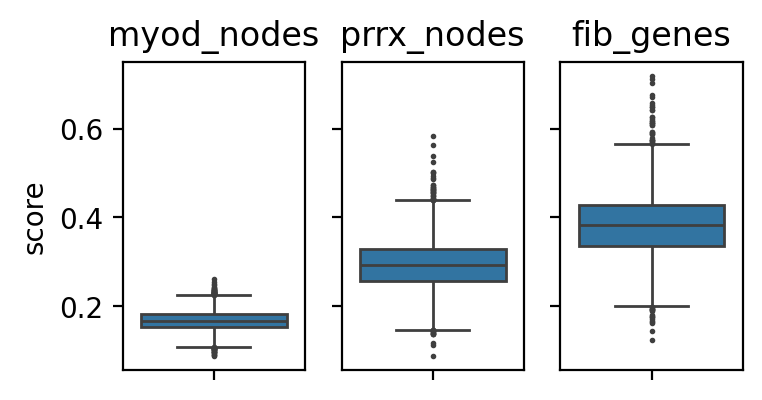

In [80]:
fig, axs = plt.subplots(1, 3, figsize=(4,2), dpi=200, sharey=True)

for i, col in enumerate(tmp.columns):
    ax = axs[i]
    
    sns.boxplot(
        tmp[col],
        fliersize=1,
        ax=ax,
    )
    
    if i == 0:
        ax.set_ylabel('score')
    
    ax.set_title(col)
    
plt.show()

# Correlation network test

PPI network (unweighted)
Assign weights based on expression levels of gene i and gene j

"assumption that two genes, which can interact at the protein level, are more likely to do so if both are highly expressed."

In [34]:
GF = nx.from_pandas_adjacency(fdf, create_using=nx.Graph) # keeps self-loops
GF.remove_edges_from(nx.selfloop_edges(GF)) # remove self-loops

print(f"N nodes: {GF.number_of_nodes()}\nN edges: {GF.number_of_edges()}")

fibgenes_nodes = list(GF.nodes())
print(len(fibgenes_nodes))

fib_genes = [
    g for g in fibgenes_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_fib_genes = list(set(fibgenes_nodes) - set(fib_genes))

print(f"N fibgenes nodes in fdata: {len(fib_genes)}")
print(f"{len(missing_fib_genes)} genes not detected.\n")


sub_GF = GF.subgraph(fib_genes)
print(f"\nN nodes: {sub_GF.number_of_nodes()}\nN edges: {sub_GF.number_of_edges()}")

N nodes: 231
N edges: 4118
231
N fibgenes nodes in fdata: 208
23 genes not detected.


N nodes: 208
N edges: 3859


In [35]:
edges = pd.DataFrame(sub_GF.edges(), columns=["gene1", "gene2"])
print(edges.shape)
edges.head()

(3859, 2)


,gene1,gene2
0,TNFRSF1B,NGF
1,TNFRSF1B,IL1R1
2,TNFRSF1B,CXCL8
3,TNFRSF1B,NFKB1
4,TNFRSF1B,IL6


In [39]:
# Pseudobulk, expression bins

aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func='sum',
    layer='raw_counts',
)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e4)
aggdata.layers['CP10K'] = aggdata.X.copy()

sc.pp.log1p(aggdata)
aggdata.layers['log_norm'] = aggdata.X.copy()

print(aggdata)

aggdata.X = aggdata.layers['log_norm'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

normalizing counts per cell
    finished (0:00:00)
AnnData object with n_obs × n_vars = 1 × 19961
    obs: 'pooled_condition'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'highly_variable_no_cc'
    uns: 'log1p'
    layers: 'sum', 'CP10K', 'log_norm'
(19961, 2)


,gene_name,Control
0,A1BG,0.556132
1,A1BG-AS1,0.040971
2,A2M,0.121208
3,A2M-AS1,0.002791
4,A4GALT,0.045369


In [40]:
df['is_tf'] = df['gene_name'].isin(tf_list)

print(df['is_tf'].value_counts())

# make expression bins

q_low = 0.25
q_high = 0.75

# Calculate thresholds for TFs and non-TFs separately
non_tf_low = df[~df['is_tf']]['Control'].quantile(q_low)
non_tf_high = df[~df['is_tf']]['Control'].quantile(q_high)

tf_low = df[df['is_tf']]['Control'].quantile(q_low)
tf_high = df[df['is_tf']]['Control'].quantile(q_high)

print("Non-TF thresholds:", non_tf_low, non_tf_high)
print("TF thresholds:", tf_low, tf_high)

def assign_expr_level(row):
    if row['is_tf']:
        if row['Control'] < tf_low:
            return 'low'
        elif row['Control'] > tf_high:
            return 'high'
        else:
            return 'mid'
    else:
        if row['Control'] < non_tf_low:
            return 'low'
        elif row['Control'] > non_tf_high:
            return 'high'
        else:
            return 'mid'

df['expr_level'] = df.apply(assign_expr_level, axis=1)

df.head()

is_tf
False    18714
True      1247
Name: count, dtype: int64
Non-TF thresholds: 0.006566123996383339 0.20461457897130192
TF thresholds: 0.024111504776474744 0.15215767044599193


,gene_name,Control,is_tf,expr_level
0,A1BG,0.556132,False,high
1,A1BG-AS1,0.040971,False,mid
2,A2M,0.121208,False,mid
3,A2M-AS1,0.002791,False,low
4,A4GALT,0.045369,False,mid


In [54]:
high_genes = set(df.loc[df['expr_level'].eq('high'), 'gene_name'])
print(len(high_genes))


edges['both_high'] = edges["gene1"].isin(high_genes) & edges["gene2"].isin(high_genes)


edges.head()

4991


,gene1,gene2,both_high
0,TNFRSF1B,NGF,False
1,TNFRSF1B,IL1R1,False
2,TNFRSF1B,CXCL8,False
3,TNFRSF1B,NFKB1,False
4,TNFRSF1B,IL6,False


In [56]:
edges['both_high'].value_counts(normalize=True)

both_high
True     0.656129
False    0.343871
Name: proportion, dtype: float64

In [51]:
high_genes = set(df.loc[df['expr_level'].eq('high'), 'gene_name'])
print(len(high_genes))


F = nx.Graph()
F.add_nodes_from(sub_GF.nodes(data=True))

# add only edges whose endpoints are both high 
mask = edges["gene1"].isin(high_genes) & edges["gene2"].isin(high_genes)

F.add_edges_from(edges.loc[mask, ["gene1", "gene2"]].itertuples(index=False, name=None))


print(f"Nodes: {F.number_of_nodes()}\nEdges: {F.number_of_edges()}")

n_edges = F.number_of_edges()
n_nodes = F.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"\nGraph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(F)}')
print(f'N connected components: {nx.number_connected_components(F)}')
print(f'Largest connected components has {len(max(nx.connected_components(F), key=len))} nodes')

4991
Nodes: 208
Edges: 2532

Graph density: 0.1176

Is connected? False
N connected components: 80
Largest connected components has 129 nodes


In [52]:
print(f"N nodes: {sub_GF.number_of_nodes()}\nN edges: {sub_GF.number_of_edges()}")

n_edges = sub_GF.number_of_edges()
n_nodes = sub_GF.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"\nGraph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(sub_GF)}')
print(f'N connected components: {nx.number_connected_components(sub_GF)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GF), key=len))} nodes')

N nodes: 208
N edges: 3859

Graph density: 0.1793

Is connected? False
N connected components: 7
Largest connected components has 200 nodes


In [38]:
fdata.X = fdata.layers['log_norm_new'].copy()

corr_method = 'spearman'
# corr_method = 'pearson'

gene_list = [g for g in fib_genes if g in fdata.var_names]


mdata = fdata[:, gene_list].copy()
print(mdata.shape)

X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=mdata.obs_names,
    columns=mdata.var_names,
)

RM = X_df.corr(method=corr_method)
print(RM.shape)
display(RM.head())

(6902, 208)
(208, 208)


gene_name,TNFRSF1B,PODN,GSTM5,OLFML3,DDR2,PBX1,PRRX1,LAMC1,PRG4,CD55,...,CEBPB,ADAM33,COL6A1,COL6A2,ADAMTS5,RUNX1,TIMP3,SRPX2,BGN,MXRA5
gene_name,,,,,,,,,,,,,,,,,,,,,
TNFRSF1B,1.000000,-0.026298,-0.004360,0.008049,0.008365,-0.008720,0.002050,0.016176,0.001720,0.006980,...,-0.007537,-0.018271,0.003994,-0.016556,-0.005704,0.020331,0.014184,0.007541,-0.009434,-0.010901
PODN,-0.026298,1.000000,0.015650,0.026415,0.044853,0.038818,0.014718,0.053430,0.021958,0.025429,...,0.032938,0.028835,0.070217,0.038837,0.003819,0.057831,0.054170,0.003490,0.049156,0.023577
GSTM5,-0.004360,0.015650,1.000000,-0.020696,0.037495,0.011222,0.025568,0.013382,-0.008769,0.012530,...,0.032112,0.023451,0.004725,-0.005736,0.032541,0.002502,-0.021583,0.027924,0.007592,-0.009257
OLFML3,0.008049,0.026415,-0.020696,1.000000,0.013787,0.020073,0.066822,0.019190,0.003132,0.002019,...,0.014903,0.009213,0.066763,0.060839,0.003667,0.016108,0.025643,-0.001265,0.018426,0.034392
DDR2,0.008365,0.044853,0.037495,0.013787,1.000000,0.094997,0.078198,0.084229,0.016425,0.043357,...,0.023376,0.001111,0.134765,0.119216,0.011301,0.048078,-0.009199,0.034335,0.054666,0.048072


In [19]:
X_df.head()

gene_name,TNFRSF1B,PODN,GSTM5,OLFML3,DDR2,PBX1,PRRX1,LAMC1,PRG4,CD55,...,CEBPB,ADAM33,COL6A1,COL6A2,ADAMTS5,RUNX1,TIMP3,SRPX2,BGN,MXRA5
AAACCAAAGGGTAGCA_control,0.0,0.000000,0.0,0.683198,0.398843,0.683198,1.371333,0.904340,0.0,0.904340,...,0.398843,0.000000,1.371333,1.854906,0.0,0.398843,1.085324,0.398843,0.000000,0.000000
AAACCAAAGTAAGGGT_control,0.0,0.000000,0.0,1.374487,0.685291,1.374487,1.088123,0.000000,0.0,1.596838,...,0.000000,0.000000,1.778631,1.932404,0.0,0.000000,1.932404,0.000000,0.685291,1.088123
AAACCATTCAGGTAGG_control,0.0,0.404783,0.0,0.404783,0.915062,0.692124,0.692124,1.703073,0.0,0.404783,...,0.000000,0.000000,1.790053,2.249460,0.0,0.000000,1.870070,0.000000,1.097247,0.000000
AAACCATTCCAGCCCT_control,0.0,0.000000,0.0,0.000000,0.919740,0.000000,0.000000,1.182633,0.0,0.562080,...,0.000000,1.182633,1.950833,1.837407,0.0,0.562080,0.000000,0.000000,0.000000,0.000000
AAACCATTCGTGACCG_control,0.0,0.000000,0.0,1.280587,1.280587,0.000000,1.673587,1.280587,0.0,0.623932,...,0.000000,0.000000,2.433176,1.824147,0.0,0.623932,0.623932,0.000000,1.005218,0.623932


(6902,)


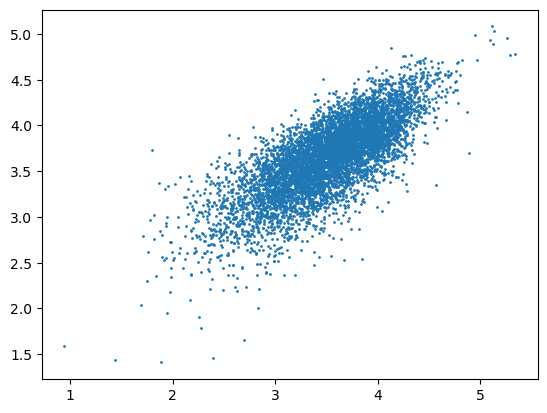

In [21]:
gene_i = 'COL1A1'

gene_j = 'COL1A2'


exp_i = X_df[gene_i]
print(exp_i.shape)

exp_j = X_df[gene_j]


plt.scatter(
    x=exp_i,
    y=exp_j,
    s=1
)

plt.xlabel(f"{gene_i} expression")
plt.ylabel(f"{gene_j} expression")

plt.show()

In [ ]:
# def get_dense_X(adata: an.AnnData, layer=None):
#     X = adata.layers[layer] if layer is not None else adata.X
#     if sp.issparse(X):
#         X = X.toarray()
#     return np.asarray(X, dtype=np.float32)


# def precompute_gene_sorts(E):
#     """
#     E: (n_cells, n_genes) dense
#     Returns:
#       order[g] : indices of cells sorted by expression of gene g
#       sorted_E[g] : sorted expression values for gene g
#     """
#     n_cells, n_genes = E.shape
#     order = []
#     sorted_E = []
#     for g in range(n_genes):
#         idx = np.argsort(E[:, g], kind="mergesort")
#         order.append(idx)
#         sorted_E.append(E[idx, g])
#     return order, sorted_E

# def rank_window_indices(order_g, inv_rank_g, k, m):
#     """
#     order_g: sorted cell indices for gene g
#     inv_rank_g: inverse permutation, inv_rank_g[cell] = rank position in order_g
#     k: focal cell index
#     m: window size (#cells in neighborhood, including the focal cell)
#     Returns slice [lo, hi) in rank space
#     """
#     r = inv_rank_g[k]
#     half = m // 2
#     lo = max(0, r - half)
#     hi = min(len(order_g), lo + m)
#     lo = max(0, hi - m)
#     return lo, hi

# def precompute_inv_ranks(order):
#     inv = []
#     for idx in order:
#         inv_rank = np.empty_like(idx)
#         inv_rank[idx] = np.arange(len(idx))
#         inv.append(inv_rank)
#     return inv


# def intersection_size(a, b):
#     # a and b are 1D arrays of cell indices (unsorted is OK; sort for linear intersect)
#     a = np.sort(a)
#     b = np.sort(b)
#     i = j = c = 0
#     while i < len(a) and j < len(b):
#         if a[i] == b[j]:
#             c += 1; i += 1; j += 1
#         elif a[i] < b[j]:
#             i += 1
#         else:
#             j += 1
#     return c


# def rho_excess_overlap(nij, ni, nj, n_cells):
#     pi = ni / n_cells
#     pj = nj / n_cells
#     pij = nij / n_cells
#     return max(0.0, pij - pi * pj)

# FINAL

## Make MYOD/PRRX1 graphs

In [60]:
# MYOD1
GM = nx.from_pandas_adjacency(mdf, create_using=nx.Graph) # keeps self-loops
GM.remove_edges_from(nx.selfloop_edges(GM)) # remove self-loops

print(f"MYOD1:\nN nodes: {GM.number_of_nodes()}\nN edges: {GM.number_of_edges()}")

n_edges = GM.number_of_edges()
n_nodes = GM.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GM)}')
print(f'N connected components: {nx.number_connected_components(GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM), key=len))} nodes\n')



# PRRX1
GP = nx.from_pandas_adjacency(pdf, create_using=nx.Graph) # keeps self-loops
GP.remove_edges_from(nx.selfloop_edges(GP)) # remove self-loops

print(f"\nPRRX1:\nN nodes: {GP.number_of_nodes()}\nN edges: {GP.number_of_edges()}")

n_edges = GP.number_of_edges()
n_nodes = GP.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

print(f'\nIs connected? {nx.is_connected(GP)}')
print(f'N connected components: {nx.number_connected_components(GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP), key=len))} nodes')



## get gene lists for 1st order genes
myod_nodes = list(GM.nodes())
prrx_nodes = list(GP.nodes())

MYOD1:
N nodes: 545
N edges: 29898
Graph density: 0.2017

Is connected? True
N connected components: 1
Largest connected components has 545 nodes


PRRX1:
N nodes: 196
N edges: 4055
Graph density: 0.2122

Is connected? True
N connected components: 1
Largest connected components has 196 nodes


## Build subgraphs

In [61]:
# Build subgraphs from control data --- remove edges where nodes are not detected

# MYOD1
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])

myod_genes = [
    g for g in myod_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_myod_genes = list(set(myod_nodes) - set(myod_genes))

print(f"N myod nodes in fdata: {len(myod_genes)}")
print(f"{len(missing_myod_genes)} genes not detected.\n")


# PRRX1
prrx_genes = [
    g for g in prrx_nodes
    if (g.startswith('ENSG') and g in gene_ids) or
       (not g.startswith('ENSG') and g in gene_names)
]

missing_prrx_genes = list(set(prrx_nodes) - set(prrx_genes))

print(f"N prrx1 nodes in fdata: {len(prrx_genes)}")
print(f"{len(missing_prrx_genes)} genes not detected.")

N myod nodes in fdata: 391
154 genes not detected.

N prrx1 nodes in fdata: 170
26 genes not detected.


In [64]:
### Build subgraphs

## ---------- only detected nodes/edges ----------
print("A subgraphs (only nodes expressed in control cells):\n")
sub_GM = GM.subgraph(myod_genes)

n_edges = sub_GM.number_of_edges()
n_nodes = sub_GM.number_of_nodes()
print(f"MYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(sub_GM)}')
print(f'N connected components: {nx.number_connected_components(sub_GM)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GM), key=len))} nodes')


sub_GP = GP.subgraph(prrx_genes)

n_edges = sub_GP.number_of_edges()
n_nodes = sub_GP.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(sub_GP)}')
print(f'N connected components: {nx.number_connected_components(sub_GP)}')
print(f'Largest connected components has {len(max(nx.connected_components(sub_GP), key=len))} nodes')


## ---------- all nodes with edges between non-detected nodes removed ----------

print("\n\nA subgraphs (all nodes, edges removed for non-expressed nodes):\n")

missing_myod_genes = set(missing_myod_genes)

GM2 = GM.copy() # keeps all nodes + edges

# remove edges from nodes not detected in control cells
edges_to_drop = [(u, v) for u, v in GM2.edges() if (u in missing_myod_genes) or (v in missing_myod_genes)]
GM2.remove_edges_from(edges_to_drop)

n_edges = GM2.number_of_edges()
n_nodes = GM2.number_of_nodes()
print(f"MYOD1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(GM2)}')
print(f'N connected components: {nx.number_connected_components(GM2)}')
print(f'Largest connected components has {len(max(nx.connected_components(GM2), key=len))} nodes')



missing_prrx_genes = set(missing_prrx_genes)

GP2 = GP.copy() # keeps all nodes + edges

# remove edges from nodes not detected in control cells
edges_to_drop = [(u, v) for u, v in GP2.edges() if (u in missing_prrx_genes) or (v in missing_prrx_genes)]
GP2.remove_edges_from(edges_to_drop)

n_edges = GP2.number_of_edges()
n_nodes = GP2.number_of_nodes()
print(f"\nPRRX1 - N nodes: {n_nodes}, N edges: {n_edges}")
density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")
print(f'Is connected? {nx.is_connected(GP2)}')
print(f'N connected components: {nx.number_connected_components(GP2)}')
print(f'Largest connected components has {len(max(nx.connected_components(GP2), key=len))} nodes')

A subgraphs (only nodes expressed in control cells):

MYOD1 - N nodes: 391, N edges: 16796
Graph density: 0.2203
Is connected? False
N connected components: 2
Largest connected components has 390 nodes

PRRX1 - N nodes: 170, N edges: 3068
Graph density: 0.2136
Is connected? True
N connected components: 1
Largest connected components has 170 nodes


A subgraphs (all nodes, edges removed for non-expressed nodes):

MYOD1 - N nodes: 545, N edges: 16796
Graph density: 0.1133
Is connected? False
N connected components: 156
Largest connected components has 390 nodes

PRRX1 - N nodes: 196, N edges: 3068
Graph density: 0.1605
Is connected? False
N connected components: 27
Largest connected components has 170 nodes
